# Multi-Stock Comparative Financial Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Stock Datasets

In [2]:
stocks = ["AAPL", "AMZN", "GOOG", "META", "NVDA"]

stock_data = {}

In [3]:
for stock in stocks:

    path = f"../Data/{stock}.csv"

    temp_df = pd.read_csv(path)

    temp_df["Date"] = pd.to_datetime(
        temp_df["Date"]
    )

    temp_df = temp_df.sort_values("Date")

    temp_df = temp_df.dropna()

    stock_data[stock] = temp_df

# Normalized Stock Performance Comparison

In [4]:
normalized_prices = pd.DataFrame()

In [5]:
for stock in stocks:

    temp_df = stock_data[stock]

    normalized_prices[stock] = (
        temp_df["Close"] /
        temp_df["Close"].iloc[0]
    )

normalized_prices["Date"] = (
    stock_data["AAPL"]["Date"].values
)

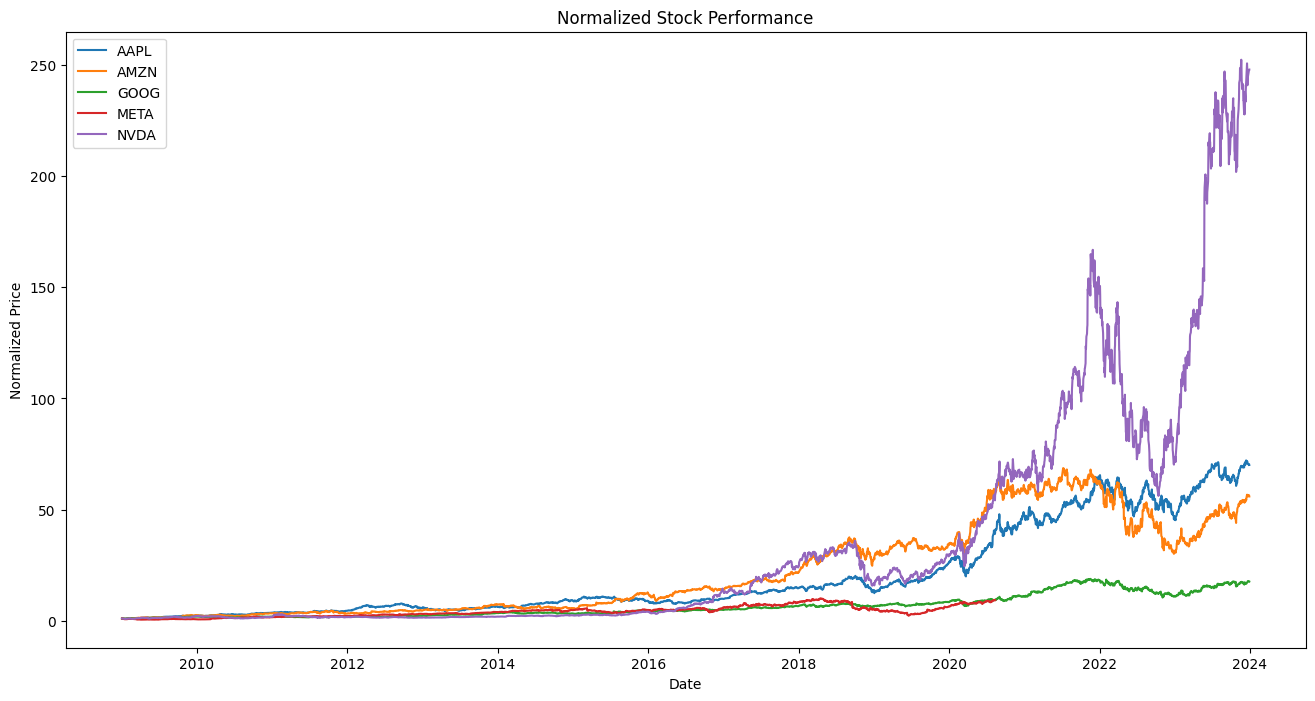

In [6]:
plt.figure(figsize=(16,8))

for stock in stocks:

    plt.plot(
        normalized_prices["Date"],
        normalized_prices[stock],
        label=stock
    )

plt.title("Normalized Stock Performance")

plt.xlabel("Date")

plt.ylabel("Normalized Price")

plt.legend()

plt.show()

# Daily Return Comparison

In [7]:
returns_df = pd.DataFrame()

In [8]:
for stock in stocks:

    temp_df = stock_data[stock]

    returns_df[stock] = (
        temp_df["Close"].pct_change()
    )

returns_df["Date"] = (
    stock_data["AAPL"]["Date"].values
)

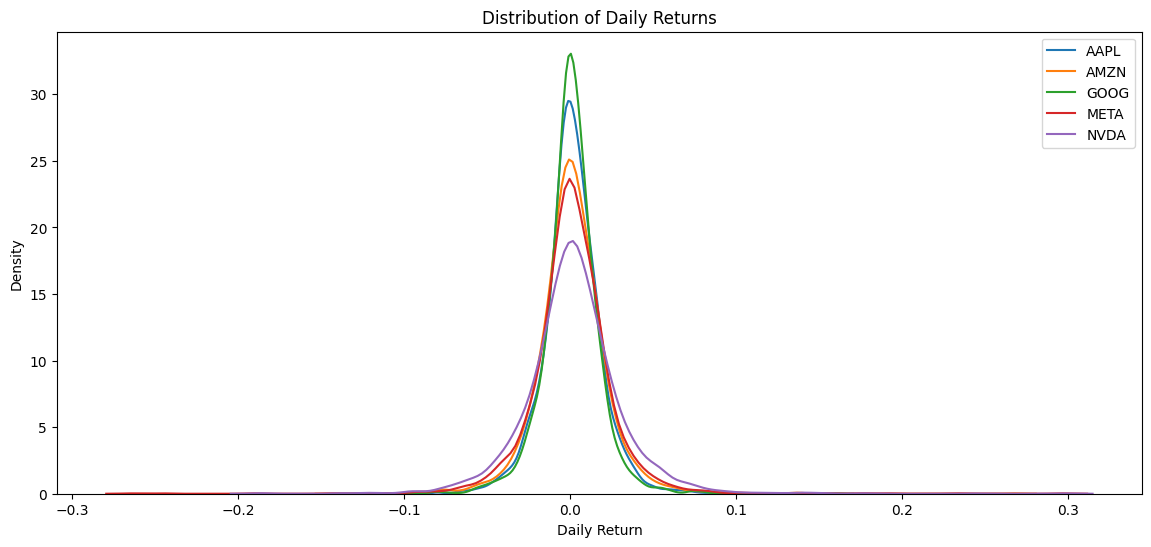

In [9]:
plt.figure(figsize=(14,6))

for stock in stocks:

    sns.kdeplot(
        returns_df[stock].dropna(),
        label=stock
    )

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.legend()

plt.show()

# Correlation Analysis

In [10]:
correlation_matrix = (
    returns_df[stocks].corr()
)

In [11]:
correlation_matrix

,AAPL,AMZN,GOOG,META,NVDA
AAPL,1.000000,0.472398,0.570600,0.000359,0.506192
AMZN,0.472398,1.000000,0.581239,0.007369,0.447627
GOOG,0.570600,0.581239,1.000000,0.009788,0.512466
META,0.000359,0.007369,0.009788,1.000000,0.022419
NVDA,0.506192,0.447627,0.512466,0.022419,1.000000


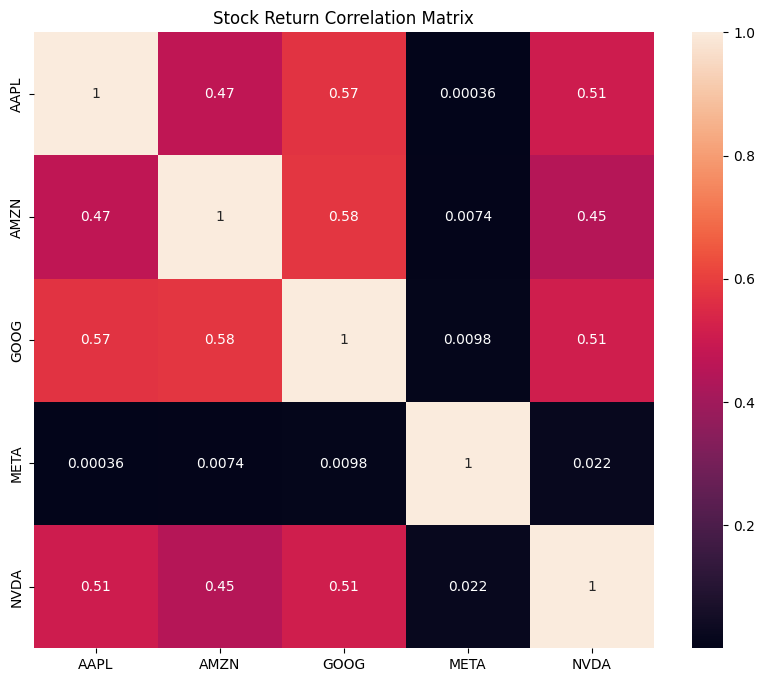

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title(
    "Stock Return Correlation Matrix"
)

plt.show()

# Volatility Comparison

In [13]:
volatility = (
    returns_df[stocks].std()
)

In [14]:
volatility.sort_values(ascending=False)

NVDA    0.028917
META    0.025280
AMZN    0.021829
AAPL    0.018010
GOOG    0.017334
dtype: float64

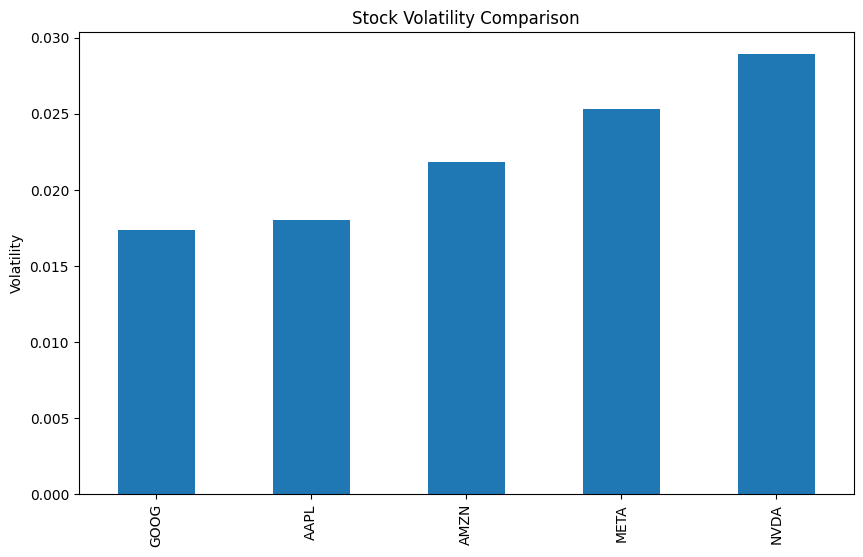

In [15]:
volatility.sort_values().plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Stock Volatility Comparison")

plt.ylabel("Volatility")

plt.show()

# Key Findings

- Normalized stock analysis revealed differences in long-term growth performance.
- Daily return distributions highlighted varying levels of volatility among companies.
- Correlation analysis showed strong relationships between several technology stocks.
- Volatility comparison identified stocks with higher market risk.
- Comparative analysis provided broader insight into market behavior across companies.